# Decision Tree Split Logic: Gini vs Entropy
### How Trees Decide Where to Split

**Video Title:** *Decision Trees: Gini vs Entropy - Which Split is Better?*

**The Question:**
- Given a dataset, where should the tree split?
- Age > 30? Income > 50K? Education = "College"?
- Two metrics decide: **Gini** and **Entropy**

**Key Concepts:**
- **Impurity**: How mixed are the classes?
- **Gini**: Probability-based impurity measure
- **Entropy**: Information theory-based measure
- **Information Gain**: Reduction in entropy after split

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyBboxPatch
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
import seaborn as sns

plt.style.use('dark_background')
np.random.seed(42)

## 1. The Problem: Where to Split?

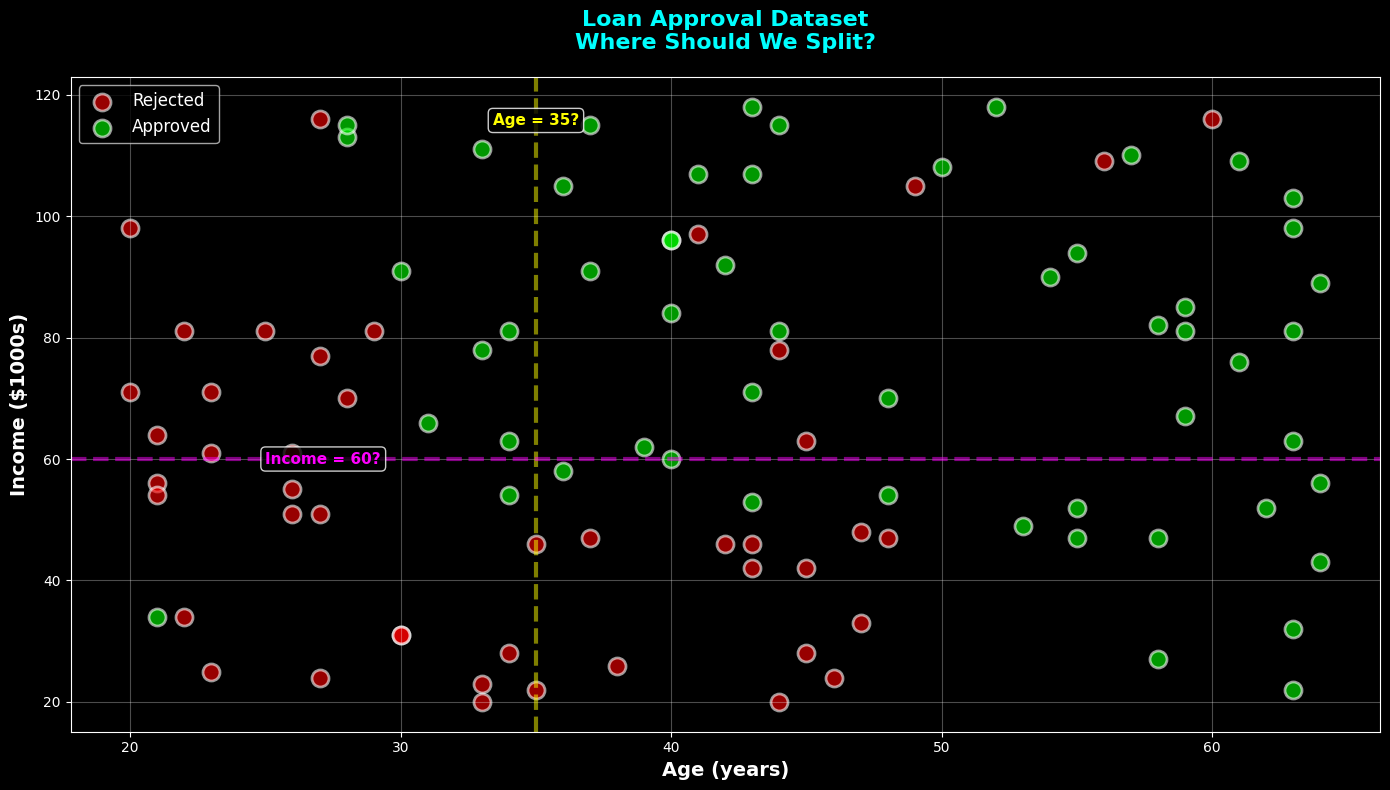

DECISION TREE CHALLENGE:
Total samples: 100
Approved: 55 (55.0%)
Rejected: 45 (45.0%)

QUESTION: Which split is best?
  - Age > 35?
  - Income > 60?
  - Some other threshold?

ANSWER: Use IMPURITY METRICS!
  - Gini Impurity
  - Entropy / Information Gain


In [2]:
# Simple 2D dataset
np.random.seed(42)

# Create data: Age vs Income, predict Loan Approval
n = 100
age = np.random.randint(20, 65, n)
income = np.random.randint(20, 120, n)  # in thousands

# Simple rule: Approve if (age > 30 AND income > 50) OR (age > 50)
y = ((age > 30) & (income > 50)) | (age > 50)
y = y.astype(int)

# Add some noise
noise_idx = np.random.choice(n, size=10, replace=False)
y[noise_idx] = 1 - y[noise_idx]

X = np.column_stack([age, income])

# Visualize
fig, ax = plt.subplots(figsize=(14, 8))

colors = ['red', 'lime']
labels = ['Rejected', 'Approved']

for class_val in [0, 1]:
    mask = y == class_val
    ax.scatter(age[mask], income[mask], 
              c=colors[class_val], s=150, alpha=0.6,
              edgecolors='white', linewidth=2,
              label=labels[class_val])

ax.set_xlabel('Age (years)', fontsize=14, fontweight='bold')
ax.set_ylabel('Income ($1000s)', fontsize=14, fontweight='bold')
ax.set_title('Loan Approval Dataset\nWhere Should We Split?', 
            fontsize=16, fontweight='bold', color='cyan', pad=20)
ax.legend(fontsize=12, loc='upper left')
ax.grid(alpha=0.3)

# Add question marks for potential splits
ax.axvline(35, color='yellow', linestyle='--', linewidth=3, alpha=0.5)
ax.text(35, 115, 'Age = 35?', fontsize=11, color='yellow', 
       fontweight='bold', ha='center',
       bbox=dict(boxstyle='round', facecolor='black', alpha=0.8))

ax.axhline(60, color='magenta', linestyle='--', linewidth=3, alpha=0.5)
ax.text(25, 60, 'Income = 60?', fontsize=11, color='magenta', 
       fontweight='bold', va='center',
       bbox=dict(boxstyle='round', facecolor='black', alpha=0.8))

plt.tight_layout()
plt.show()

print("DECISION TREE CHALLENGE:")
print("="*70)
print(f"Total samples: {n}")
print(f"Approved: {np.sum(y == 1)} ({np.sum(y == 1)/n*100:.1f}%)")
print(f"Rejected: {np.sum(y == 0)} ({np.sum(y == 0)/n*100:.1f}%)")
print("\nQUESTION: Which split is best?")
print("  - Age > 35?")
print("  - Income > 60?")
print("  - Some other threshold?")
print("\nANSWER: Use IMPURITY METRICS!")
print("  - Gini Impurity")
print("  - Entropy / Information Gain")
print("="*70)

## 2. Gini Impurity: Probability of Misclassification

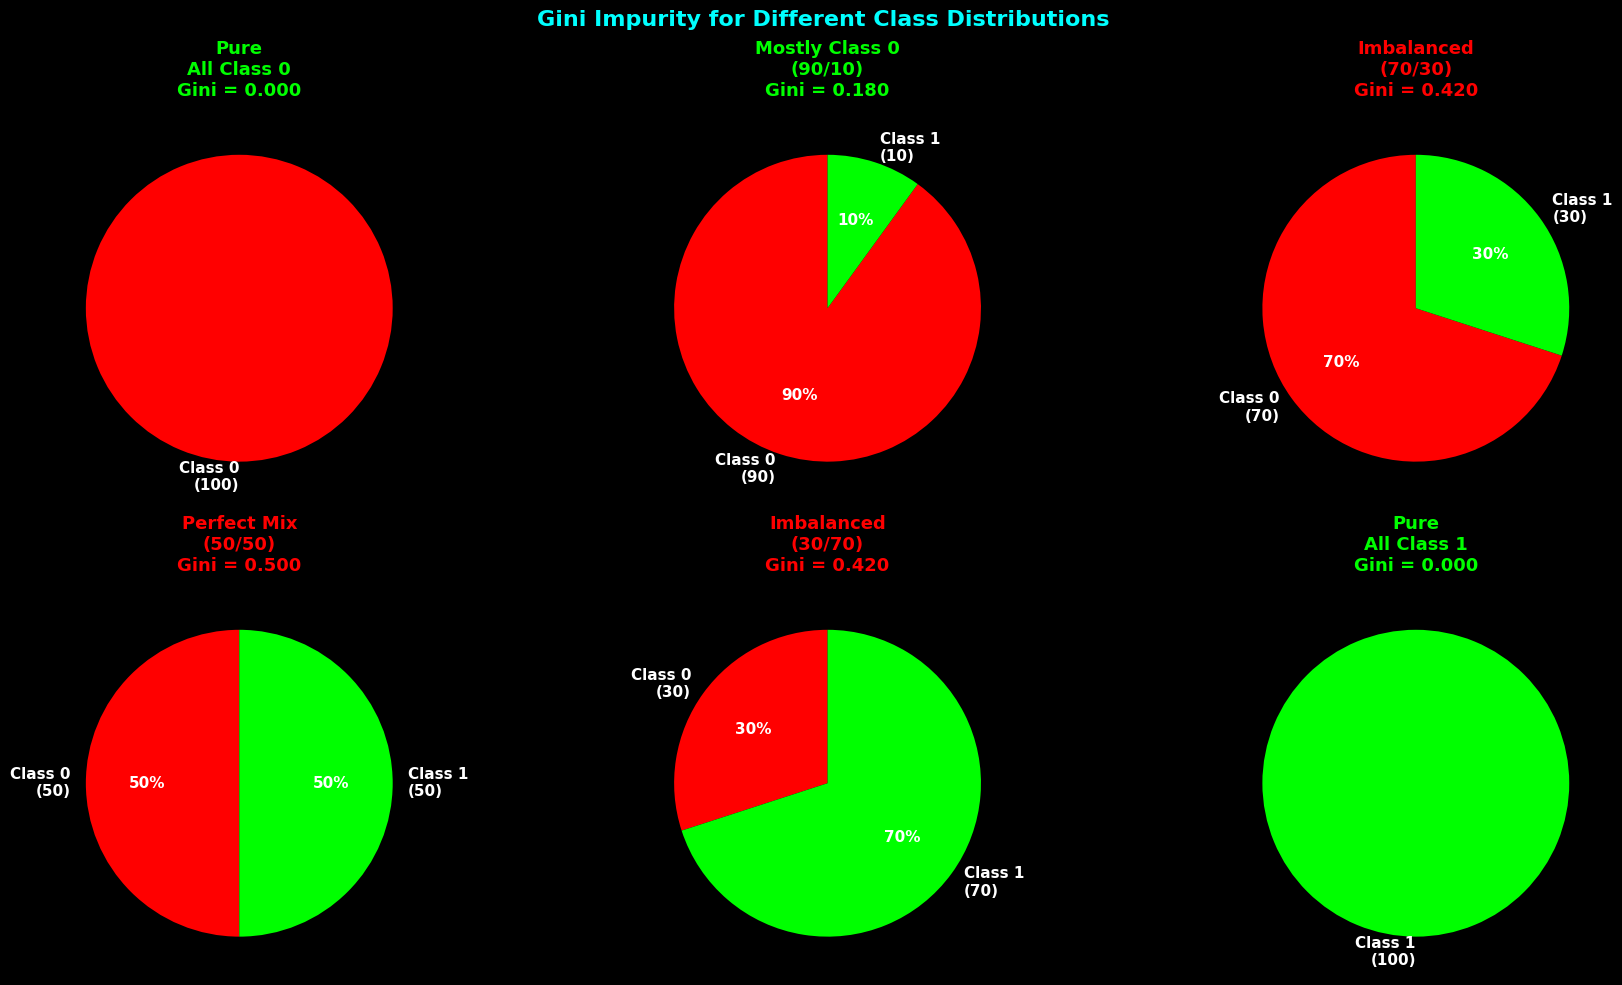


GINI IMPURITY:
Formula: Gini = 1 - Σ(pᵢ²)
  where pᵢ = probability of class i

INTERPRETATION:
  Gini = 0.0 → Pure (all same class) ✓ BEST
  Gini = 0.5 → Maximum impurity (50-50 split) ✗ WORST

INTUITION:
  Probability of misclassifying a randomly chosen element
  if we label it randomly according to class distribution

EXAMPLE: 50-50 split
  p₀ = 0.5, p₁ = 0.5
  Gini = 1 - (0.5² + 0.5²) = 1 - 0.5 = 0.5

GOAL: Find splits that MINIMIZE Gini!


In [3]:
# Gini impurity function
def gini_impurity(y):
    """
    Gini = 1 - Σ(p_i²)
    where p_i is the probability of class i
    """
    if len(y) == 0:
        return 0
    
    classes, counts = np.unique(y, return_counts=True)
    probabilities = counts / len(y)
    gini = 1 - np.sum(probabilities ** 2)
    return gini

# Visualize Gini for different class distributions
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

# Different scenarios
scenarios = [
    {'class_0': 100, 'class_1': 0, 'label': 'Pure\nAll Class 0'},
    {'class_0': 90, 'class_1': 10, 'label': 'Mostly Class 0\n(90/10)'},
    {'class_0': 70, 'class_1': 30, 'label': 'Imbalanced\n(70/30)'},
    {'class_0': 50, 'class_1': 50, 'label': 'Perfect Mix\n(50/50)'},
    {'class_0': 30, 'class_1': 70, 'label': 'Imbalanced\n(30/70)'},
    {'class_0': 0, 'class_1': 100, 'label': 'Pure\nAll Class 1'},
]

for idx, scenario in enumerate(scenarios):
    ax = axes[idx]
    
    c0 = scenario['class_0']
    c1 = scenario['class_1']
    y_scenario = np.array([0]*c0 + [1]*c1)
    
    # Calculate Gini
    gini = gini_impurity(y_scenario)
    
    # Plot pie chart
    sizes = [c0, c1]
    colors_pie = ['red', 'lime']
    labels_pie = [f'Class 0\n({c0})', f'Class 1\n({c1})']
    
    if c0 > 0 and c1 > 0:
        wedges, texts, autotexts = ax.pie(sizes, labels=labels_pie, colors=colors_pie,
                                          autopct='%1.0f%%', startangle=90,
                                          textprops={'fontsize': 11, 'fontweight': 'bold'})
    elif c0 > 0:
        wedges, texts = ax.pie([c0], labels=[labels_pie[0]], colors=[colors_pie[0]],
                               startangle=90,
                               textprops={'fontsize': 11, 'fontweight': 'bold'})
    else:
        wedges, texts = ax.pie([c1], labels=[labels_pie[1]], colors=[colors_pie[1]],
                               startangle=90,
                               textprops={'fontsize': 11, 'fontweight': 'bold'})
    
    # Color for Gini value
    gini_color = 'lime' if gini < 0.2 else 'yellow' if gini < 0.4 else 'red'
    
    ax.set_title(f"{scenario['label']}\nGini = {gini:.3f}", 
                fontsize=13, fontweight='bold', color=gini_color, pad=15)

plt.suptitle('Gini Impurity for Different Class Distributions', 
            fontsize=16, fontweight='bold', color='cyan', y=0.98)
plt.tight_layout()
plt.show()

print("\nGINI IMPURITY:")
print("="*70)
print("Formula: Gini = 1 - Σ(pᵢ²)")
print("  where pᵢ = probability of class i")
print("\nINTERPRETATION:")
print("  Gini = 0.0 → Pure (all same class) ✓ BEST")
print("  Gini = 0.5 → Maximum impurity (50-50 split) ✗ WORST")
print("\nINTUITION:")
print("  Probability of misclassifying a randomly chosen element")
print("  if we label it randomly according to class distribution")
print("\nEXAMPLE: 50-50 split")
print("  p₀ = 0.5, p₁ = 0.5")
print("  Gini = 1 - (0.5² + 0.5²) = 1 - 0.5 = 0.5")
print("\nGOAL: Find splits that MINIMIZE Gini!")
print("="*70)

## 3. Entropy: Information Theory Measure

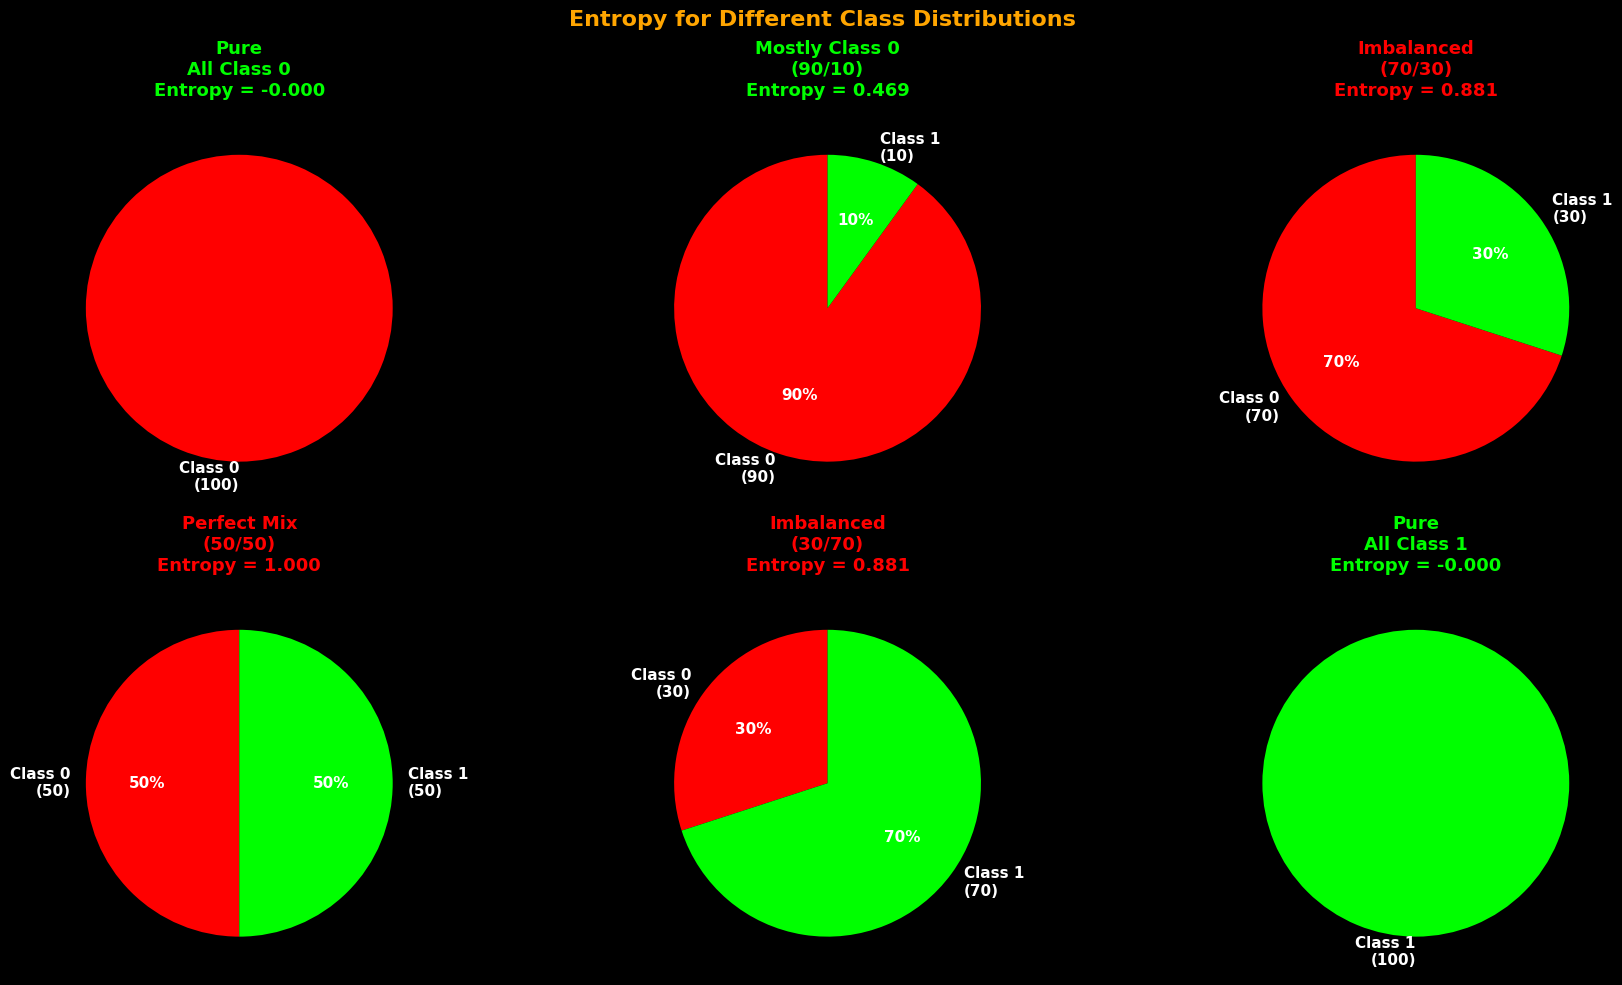


ENTROPY:
Formula: Entropy = -Σ(pᵢ × log₂(pᵢ))
  where pᵢ = probability of class i

INTERPRETATION:
  Entropy = 0.0 → Pure (all same class) ✓ BEST
  Entropy = 1.0 → Maximum uncertainty (50-50 binary) ✗ WORST

INTUITION:
  Average number of bits needed to encode class information
  Measure of 'surprise' or 'uncertainty'

EXAMPLE: 50-50 split
  p₀ = 0.5, p₁ = 0.5
  Entropy = -(0.5×log₂(0.5) + 0.5×log₂(0.5))
          = -(0.5×(-1) + 0.5×(-1))
          = -(-1) = 1.0

GOAL: Find splits that MINIMIZE Entropy!


In [4]:
# Entropy function
def entropy(y):
    """
    Entropy = -Σ(p_i × log₂(p_i))
    where p_i is the probability of class i
    """
    if len(y) == 0:
        return 0
    
    classes, counts = np.unique(y, return_counts=True)
    probabilities = counts / len(y)
    
    # Avoid log(0)
    probabilities = probabilities[probabilities > 0]
    ent = -np.sum(probabilities * np.log2(probabilities))
    return ent

# Visualize Entropy for the same scenarios
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, scenario in enumerate(scenarios):
    ax = axes[idx]
    
    c0 = scenario['class_0']
    c1 = scenario['class_1']
    y_scenario = np.array([0]*c0 + [1]*c1)
    
    # Calculate Entropy
    ent = entropy(y_scenario)
    
    # Plot pie chart (same as before)
    sizes = [c0, c1]
    colors_pie = ['red', 'lime']
    labels_pie = [f'Class 0\n({c0})', f'Class 1\n({c1})']
    
    if c0 > 0 and c1 > 0:
        wedges, texts, autotexts = ax.pie(sizes, labels=labels_pie, colors=colors_pie,
                                          autopct='%1.0f%%', startangle=90,
                                          textprops={'fontsize': 11, 'fontweight': 'bold'})
    elif c0 > 0:
        wedges, texts = ax.pie([c0], labels=[labels_pie[0]], colors=[colors_pie[0]],
                               startangle=90,
                               textprops={'fontsize': 11, 'fontweight': 'bold'})
    else:
        wedges, texts = ax.pie([c1], labels=[labels_pie[1]], colors=[colors_pie[1]],
                               startangle=90,
                               textprops={'fontsize': 11, 'fontweight': 'bold'})
    
    # Color for Entropy value
    ent_color = 'lime' if ent < 0.5 else 'yellow' if ent < 0.8 else 'red'
    
    ax.set_title(f"{scenario['label']}\nEntropy = {ent:.3f}", 
                fontsize=13, fontweight='bold', color=ent_color, pad=15)

plt.suptitle('Entropy for Different Class Distributions', 
            fontsize=16, fontweight='bold', color='orange', y=0.98)
plt.tight_layout()
plt.show()

print("\nENTROPY:")
print("="*70)
print("Formula: Entropy = -Σ(pᵢ × log₂(pᵢ))")
print("  where pᵢ = probability of class i")
print("\nINTERPRETATION:")
print("  Entropy = 0.0 → Pure (all same class) ✓ BEST")
print("  Entropy = 1.0 → Maximum uncertainty (50-50 binary) ✗ WORST")
print("\nINTUITION:")
print("  Average number of bits needed to encode class information")
print("  Measure of 'surprise' or 'uncertainty'")
print("\nEXAMPLE: 50-50 split")
print("  p₀ = 0.5, p₁ = 0.5")
print("  Entropy = -(0.5×log₂(0.5) + 0.5×log₂(0.5))")
print("          = -(0.5×(-1) + 0.5×(-1))")
print("          = -(-1) = 1.0")
print("\nGOAL: Find splits that MINIMIZE Entropy!")
print("="*70)

## 4. Gini vs Entropy: Side-by-Side Comparison

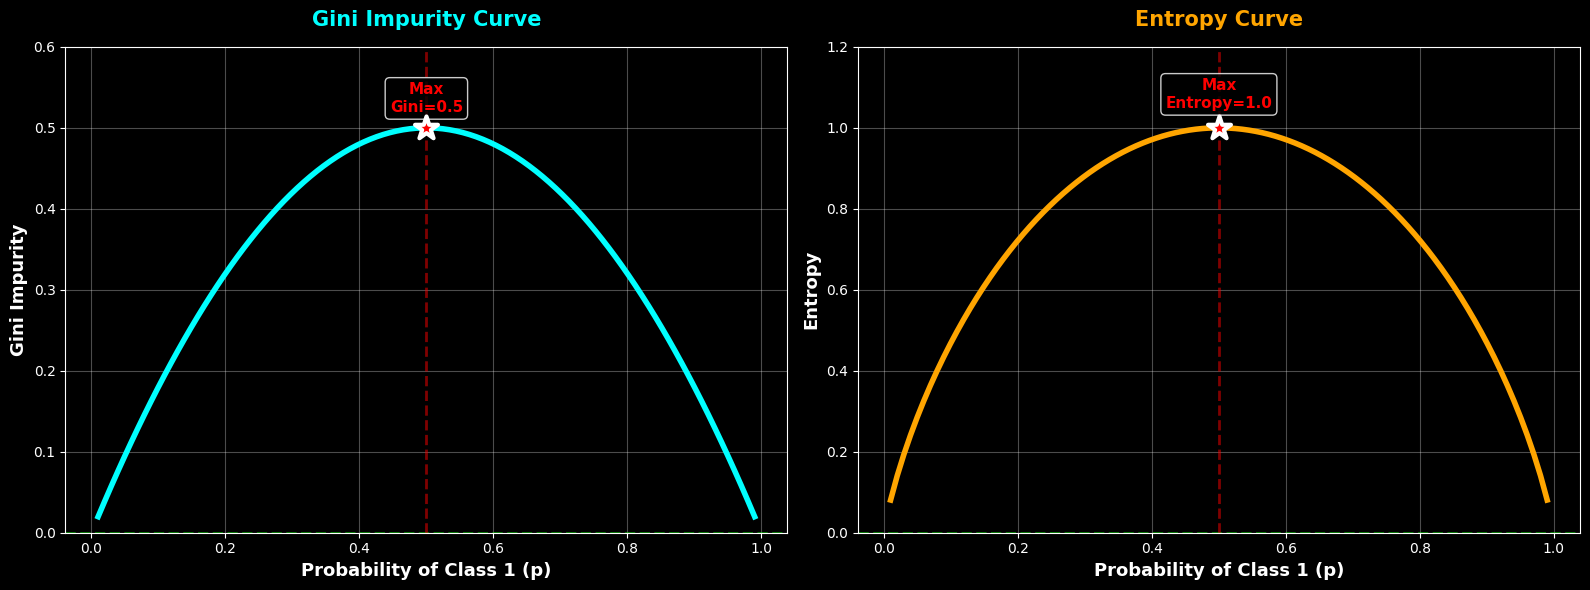

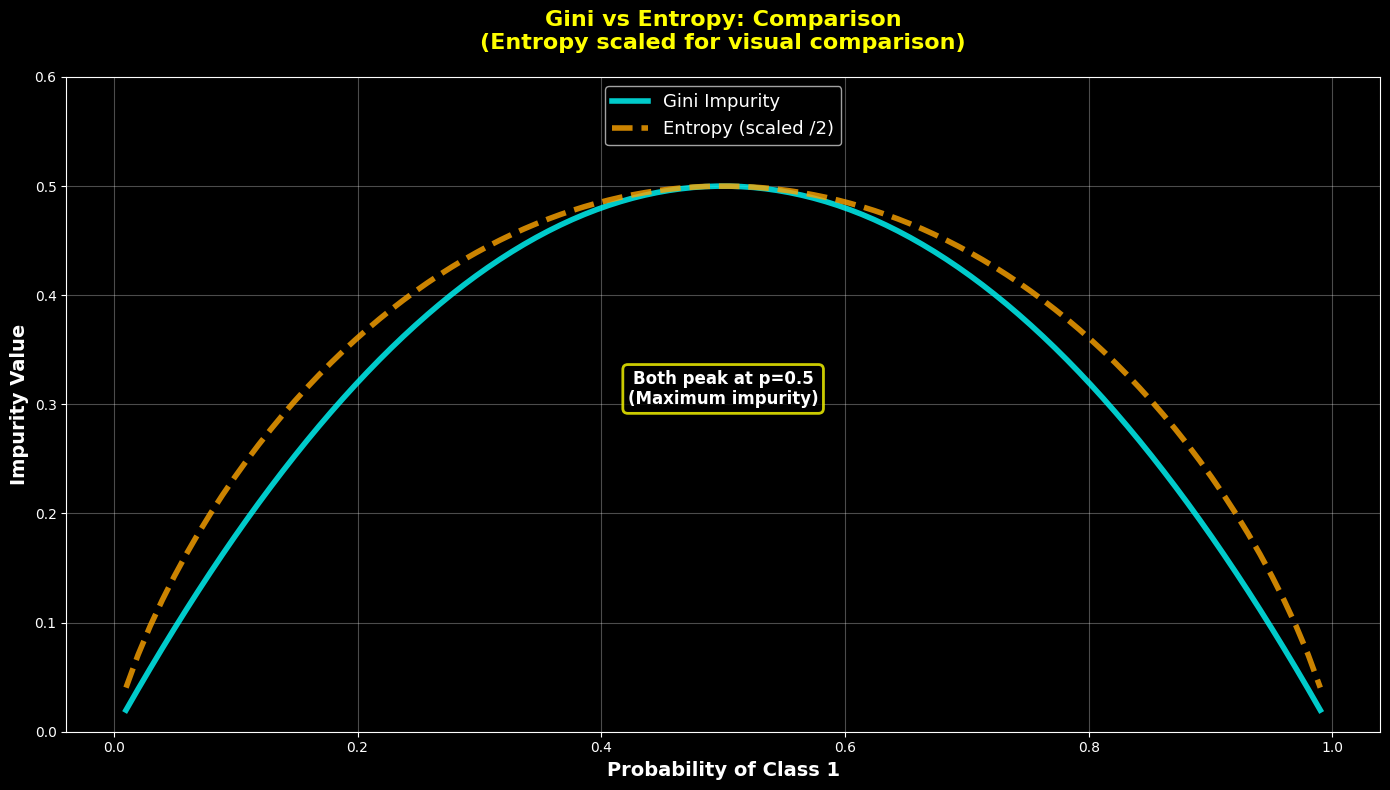


GINI vs ENTROPY COMPARISON:
SIMILARITIES:
  ✓ Both measure impurity/uncertainty
  ✓ Both = 0 for pure nodes
  ✓ Both max at 50-50 split
  ✓ Both symmetric around p=0.5
  ✓ Both lead to similar trees (usually)

DIFFERENCES:
  Gini: Simpler computation (no log)
  Gini: Range [0, 0.5] for binary
  Entropy: Uses logarithm (information theory)
  Entropy: Range [0, 1] for binary
  Entropy: Slightly more sensitive to changes

WHICH TO USE?
  → Gini: Faster (default in sklearn)
  → Entropy: Slightly more balanced trees
  → In practice: Very similar results!


In [5]:
# Plot Gini vs Entropy curves
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Probability range for binary classification
p = np.linspace(0.01, 0.99, 100)  # Probability of class 1

# Calculate Gini for each p
gini_values = 1 - (p**2 + (1-p)**2)

# Calculate Entropy for each p
entropy_values = -(p * np.log2(p) + (1-p) * np.log2(1-p))

# Plot Gini
axes[0].plot(p, gini_values, linewidth=4, color='cyan', label='Gini')
axes[0].axhline(0, color='lime', linestyle='--', linewidth=2, alpha=0.5)
axes[0].axvline(0.5, color='red', linestyle='--', linewidth=2, alpha=0.5)
axes[0].scatter([0.5], [0.5], s=300, c='red', marker='*', 
               edgecolors='white', linewidth=3, zorder=5)
axes[0].text(0.5, 0.52, 'Max\nGini=0.5', ha='center', fontsize=11, 
            color='red', fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='black', alpha=0.8))

axes[0].set_xlabel('Probability of Class 1 (p)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Gini Impurity', fontsize=13, fontweight='bold')
axes[0].set_title('Gini Impurity Curve', fontsize=15, fontweight='bold', 
                 color='cyan', pad=15)
axes[0].grid(alpha=0.3)
axes[0].set_ylim(0, 0.6)

# Plot Entropy
axes[1].plot(p, entropy_values, linewidth=4, color='orange', label='Entropy')
axes[1].axhline(0, color='lime', linestyle='--', linewidth=2, alpha=0.5)
axes[1].axvline(0.5, color='red', linestyle='--', linewidth=2, alpha=0.5)
axes[1].scatter([0.5], [1.0], s=300, c='red', marker='*', 
               edgecolors='white', linewidth=3, zorder=5)
axes[1].text(0.5, 1.05, 'Max\nEntropy=1.0', ha='center', fontsize=11, 
            color='red', fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='black', alpha=0.8))

axes[1].set_xlabel('Probability of Class 1 (p)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Entropy', fontsize=13, fontweight='bold')
axes[1].set_title('Entropy Curve', fontsize=15, fontweight='bold', 
                 color='orange', pad=15)
axes[1].grid(alpha=0.3)
axes[1].set_ylim(0, 1.2)

plt.tight_layout()
plt.show()

# Overlay comparison
fig, ax = plt.subplots(figsize=(14, 8))

# Normalize entropy to [0, 0.5] for comparison
entropy_normalized = entropy_values / 2

ax.plot(p, gini_values, linewidth=4, color='cyan', label='Gini Impurity', alpha=0.8)
ax.plot(p, entropy_normalized, linewidth=4, color='orange', 
       label='Entropy (scaled /2)', alpha=0.8, linestyle='--')

ax.set_xlabel('Probability of Class 1', fontsize=14, fontweight='bold')
ax.set_ylabel('Impurity Value', fontsize=14, fontweight='bold')
ax.set_title('Gini vs Entropy: Comparison\n(Entropy scaled for visual comparison)', 
            fontsize=16, fontweight='bold', color='yellow', pad=20)
ax.legend(fontsize=13, loc='upper center')
ax.grid(alpha=0.3)
ax.set_ylim(0, 0.6)

# Highlight similarities
ax.text(0.5, 0.3, 'Both peak at p=0.5\n(Maximum impurity)', 
       ha='center', fontsize=12, color='white', fontweight='bold',
       bbox=dict(boxstyle='round', facecolor='black', alpha=0.8,
                edgecolor='yellow', linewidth=2))

plt.tight_layout()
plt.show()

print("\nGINI vs ENTROPY COMPARISON:")
print("="*70)
print("SIMILARITIES:")
print("  ✓ Both measure impurity/uncertainty")
print("  ✓ Both = 0 for pure nodes")
print("  ✓ Both max at 50-50 split")
print("  ✓ Both symmetric around p=0.5")
print("  ✓ Both lead to similar trees (usually)")
print("\nDIFFERENCES:")
print("  Gini: Simpler computation (no log)")
print("  Gini: Range [0, 0.5] for binary")
print("  Entropy: Uses logarithm (information theory)")
print("  Entropy: Range [0, 1] for binary")
print("  Entropy: Slightly more sensitive to changes")
print("\nWHICH TO USE?")
print("  → Gini: Faster (default in sklearn)")
print("  → Entropy: Slightly more balanced trees")
print("  → In practice: Very similar results!")
print("="*70)

## 5. Finding Best Split: Step-by-Step


FINDING BEST SPLIT:
Parent node Gini: 0.495

Best split on AGE:
  Threshold: Age ≤ 27
  Gini Gain: 0.116

Best split on INCOME:
  Threshold: Income ≤ 51
  Gini Gain: 0.085

WINNER: Age ≤ 27 (Higher Gini Gain!)


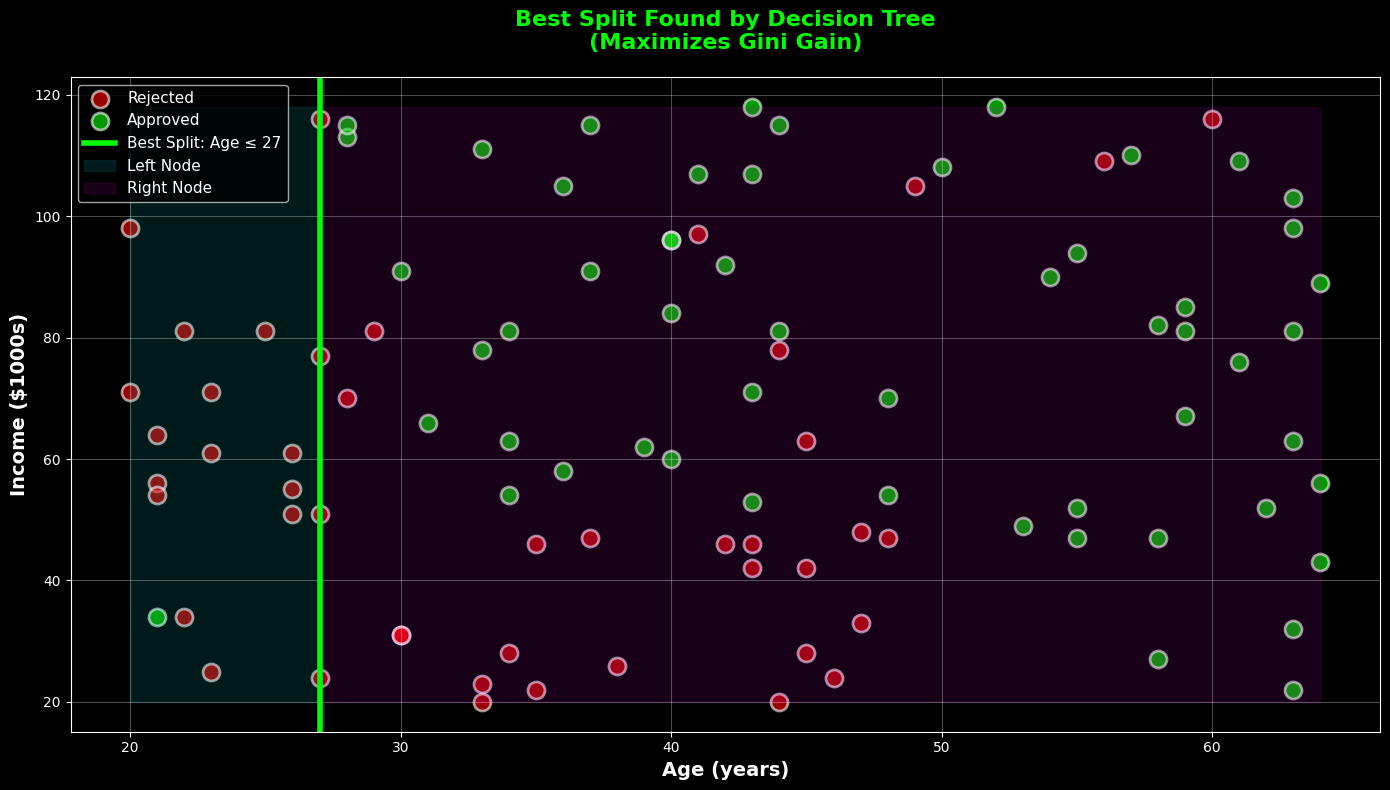

In [6]:
# Function to find best split
def find_best_split_gini(X, y, feature_idx):
    """
    Find best threshold for a given feature using Gini
    """
    best_gini_gain = -1
    best_threshold = None
    
    # Parent Gini
    parent_gini = gini_impurity(y)
    
    # Try all unique values as thresholds
    thresholds = np.unique(X[:, feature_idx])
    
    results = []
    
    for threshold in thresholds:
        # Split data
        left_mask = X[:, feature_idx] <= threshold
        right_mask = ~left_mask
        
        if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
            continue
        
        # Calculate weighted Gini
        n = len(y)
        n_left = np.sum(left_mask)
        n_right = np.sum(right_mask)
        
        gini_left = gini_impurity(y[left_mask])
        gini_right = gini_impurity(y[right_mask])
        
        weighted_gini = (n_left/n * gini_left) + (n_right/n * gini_right)
        gini_gain = parent_gini - weighted_gini
        
        results.append({
            'threshold': threshold,
            'gini_gain': gini_gain,
            'weighted_gini': weighted_gini,
            'n_left': n_left,
            'n_right': n_right,
            'gini_left': gini_left,
            'gini_right': gini_right
        })
        
        if gini_gain > best_gini_gain:
            best_gini_gain = gini_gain
            best_threshold = threshold
    
    return best_threshold, best_gini_gain, parent_gini, results

# Find best split for Age
best_age_thresh, best_age_gain, parent_gini, age_results = find_best_split_gini(X, y, 0)

# Find best split for Income
best_income_thresh, best_income_gain, _, income_results = find_best_split_gini(X, y, 1)

print("\nFINDING BEST SPLIT:")
print("="*70)
print(f"Parent node Gini: {parent_gini:.3f}")
print(f"\nBest split on AGE:")
print(f"  Threshold: Age ≤ {best_age_thresh}")
print(f"  Gini Gain: {best_age_gain:.3f}")
print(f"\nBest split on INCOME:")
print(f"  Threshold: Income ≤ {best_income_thresh}")
print(f"  Gini Gain: {best_income_gain:.3f}")
print(f"\n{'WINNER:':} ", end="")
if best_age_gain > best_income_gain:
    print(f"Age ≤ {best_age_thresh} (Higher Gini Gain!)")
    winner_feature = 0
    winner_thresh = best_age_thresh
else:
    print(f"Income ≤ {best_income_thresh} (Higher Gini Gain!)")
    winner_feature = 1
    winner_thresh = best_income_thresh
print("="*70)

# Visualize the split
fig, ax = plt.subplots(figsize=(14, 8))

# Plot data
for class_val in [0, 1]:
    mask = y == class_val
    ax.scatter(age[mask], income[mask], 
              c=colors[class_val], s=150, alpha=0.6,
              edgecolors='white', linewidth=2,
              label=labels[class_val])

# Draw winning split
if winner_feature == 0:  # Age
    ax.axvline(winner_thresh, color='lime', linewidth=4, 
              label=f'Best Split: Age ≤ {winner_thresh}')
    ax.fill_betweenx([income.min(), income.max()], age.min(), winner_thresh, 
                     alpha=0.1, color='cyan', label='Left Node')
    ax.fill_betweenx([income.min(), income.max()], winner_thresh, age.max(), 
                     alpha=0.1, color='magenta', label='Right Node')
else:  # Income
    ax.axhline(winner_thresh, color='lime', linewidth=4, 
              label=f'Best Split: Income ≤ {winner_thresh}')
    ax.fill_between([age.min(), age.max()], income.min(), winner_thresh, 
                    alpha=0.1, color='cyan', label='Left Node')
    ax.fill_between([age.min(), age.max()], winner_thresh, income.max(), 
                    alpha=0.1, color='magenta', label='Right Node')

ax.set_xlabel('Age (years)', fontsize=14, fontweight='bold')
ax.set_ylabel('Income ($1000s)', fontsize=14, fontweight='bold')
ax.set_title('Best Split Found by Decision Tree\n(Maximizes Gini Gain)', 
            fontsize=16, fontweight='bold', color='lime', pad=20)
ax.legend(fontsize=11, loc='upper left')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Building a Complete Tree

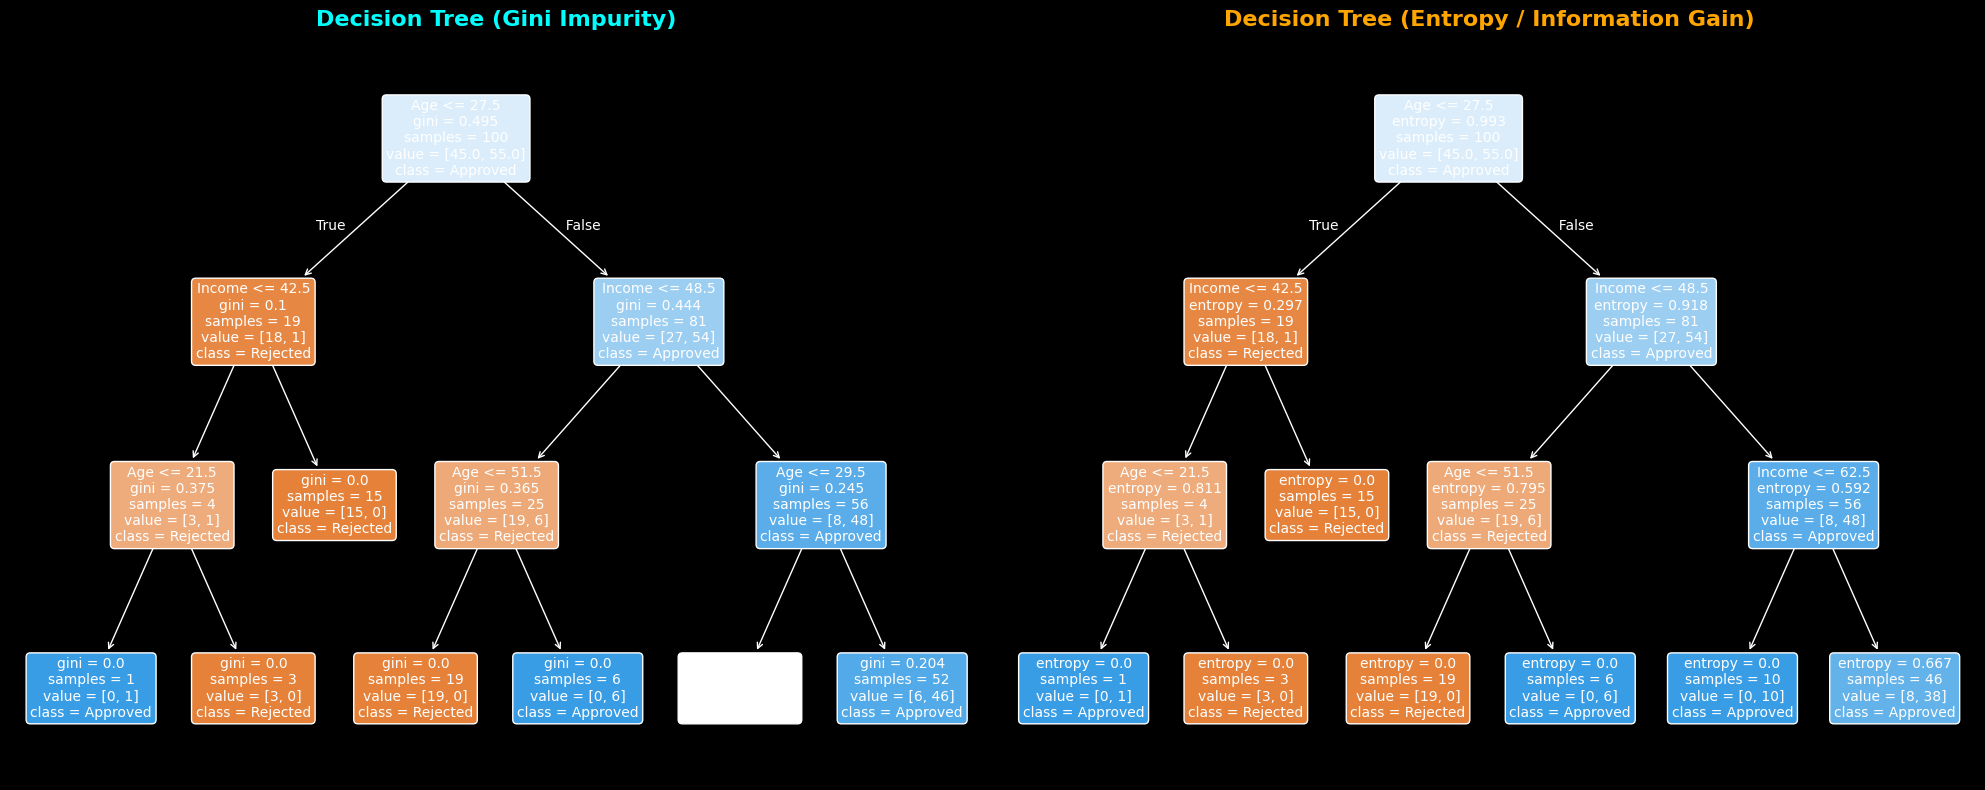


TREE COMPARISON:
Gini Tree:
  Depth: 3
  Leaves: 7
  Training Accuracy: 92.0%

Entropy Tree:
  Depth: 3
  Leaves: 7
  Training Accuracy: 92.0%

OBSERVATION: Very similar trees!
  → In practice, Gini and Entropy give similar results
  → Choose based on computational preference


In [7]:
# Train decision trees with both criteria
dt_gini = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
dt_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)

dt_gini.fit(X, y)
dt_entropy.fit(X, y)

# Visualize both trees
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Gini tree
plot_tree(dt_gini, ax=axes[0], 
         feature_names=['Age', 'Income'],
         class_names=['Rejected', 'Approved'],
         filled=True, rounded=True, fontsize=10)
axes[0].set_title('Decision Tree (Gini Impurity)', 
                 fontsize=16, fontweight='bold', color='cyan', pad=15)

# Entropy tree
plot_tree(dt_entropy, ax=axes[1], 
         feature_names=['Age', 'Income'],
         class_names=['Rejected', 'Approved'],
         filled=True, rounded=True, fontsize=10)
axes[1].set_title('Decision Tree (Entropy / Information Gain)', 
                 fontsize=16, fontweight='bold', color='orange', pad=15)

plt.tight_layout()
plt.show()

print("\nTREE COMPARISON:")
print("="*70)
print(f"Gini Tree:")
print(f"  Depth: {dt_gini.get_depth()}")
print(f"  Leaves: {dt_gini.get_n_leaves()}")
print(f"  Training Accuracy: {dt_gini.score(X, y):.1%}")
print(f"\nEntropy Tree:")
print(f"  Depth: {dt_entropy.get_depth()}")
print(f"  Leaves: {dt_entropy.get_n_leaves()}")
print(f"  Training Accuracy: {dt_entropy.score(X, y):.1%}")
print("\nOBSERVATION: Very similar trees!")
print("  → In practice, Gini and Entropy give similar results")
print("  → Choose based on computational preference")
print("="*70)

## 7. Key Takeaways

### How Decision Trees Split:

**The Algorithm:**
1. Start with all data at root
2. For each feature:
   - Try all possible thresholds
   - Calculate impurity after split
   - Choose split with lowest impurity (or highest gain)
3. Recursively split child nodes
4. Stop when:
   - Pure node (Gini=0 or Entropy=0)
   - Max depth reached
   - Min samples reached

### Gini Impurity:

**Formula:** Gini = 1 - Σ(p_i²)

**Range:** [0, 0.5] for binary classification
- 0 = Pure (all same class)
- 0.5 = Maximum impurity (50-50)

**Intuition:** Probability of misclassification if we randomly label based on class distribution

**Pros:**
- ✓ Faster to compute (no logarithm)
- ✓ Default in sklearn
- ✓ Works well in practice

**Example:**
- 100 samples: 70 class A, 30 class B
- p_A = 0.7, p_B = 0.3
- Gini = 1 - (0.7² + 0.3²) = 1 - 0.58 = 0.42

### Entropy:

**Formula:** Entropy = -Σ(p_i × log₂(p_i))

**Range:** [0, 1] for binary classification
- 0 = Pure (all same class)
- 1 = Maximum uncertainty (50-50)

**Intuition:** Average bits needed to encode class information; measure of "surprise"

**Pros:**
- ✓ Information theory foundation
- ✓ Slightly more balanced trees
- ✓ More sensitive to probability changes

**Cons:**
- ✗ Slower (logarithm computation)

**Example:**
- 100 samples: 70 class A, 30 class B
- p_A = 0.7, p_B = 0.3
- Entropy = -(0.7×log₂(0.7) + 0.3×log₂(0.3))
- = -(0.7×(-0.51) + 0.3×(-1.74))
- = 0.88

### Information Gain:

**Formula:** IG = Entropy(parent) - Weighted_Avg(Entropy(children))

**Goal:** Maximize information gain = Minimize entropy after split

**Example:**
- Parent: 100 samples (50-50) → Entropy = 1.0
- Split:
  - Left: 40 samples (30 A, 10 B) → Entropy = 0.81
  - Right: 60 samples (20 A, 40 B) → Entropy = 0.92
- Weighted Entropy = (40/100)×0.81 + (60/100)×0.92 = 0.88
- Information Gain = 1.0 - 0.88 = 0.12

### Gini Gain:

**Formula:** GG = Gini(parent) - Weighted_Avg(Gini(children))

**Goal:** Maximize Gini gain = Minimize Gini after split

### Comparison:

| Aspect | Gini | Entropy |
|--------|------|----------|
| **Formula** | 1 - Σ(p²) | -Σ(p×log₂(p)) |
| **Range** | [0, 0.5] | [0, 1] |
| **Computation** | Faster | Slower (log) |
| **Default** | sklearn | C4.5/ID3 |
| **Results** | Similar | Similar |
| **Sensitivity** | Less | More |

### Which to Use?

**Gini (Recommended):**
- ✓ Faster (important for large datasets)
- ✓ Simpler computation
- ✓ Default choice

**Entropy:**
- Use if you prefer information theory interpretation
- Slightly more balanced trees (minor difference)

**In Practice:**
- Both give very similar trees
- Difference is usually negligible
- Stick with Gini unless you have specific reason

### Remember:
- **Lower impurity = Better split**
- **Pure node = Gini/Entropy = 0**
- **Maximum impurity at 50-50 split**
- **Try all features and thresholds** to find best split
- **Gini is faster**, Entropy is more interpretable
- **Both work well** in practice! 🎯